In [11]:
# 현재 주피터 커널에 setuptools 강제 설치
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.


c:\dev\project\Service_Stock_Analysis\.venv\Scripts\python.exe: No module named pip


In [12]:
%pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.


c:\dev\project\Service_Stock_Analysis\.venv\Scripts\python.exe: No module named pip


In [14]:
# 임시 해결책: setuptools가 distutils 역할을 하도록 속임
try:
    import setuptools.dist
except ImportError:
    pass

[*********************100%***********************]  1 of 1 completed

^SOX 데이터 수집 중...


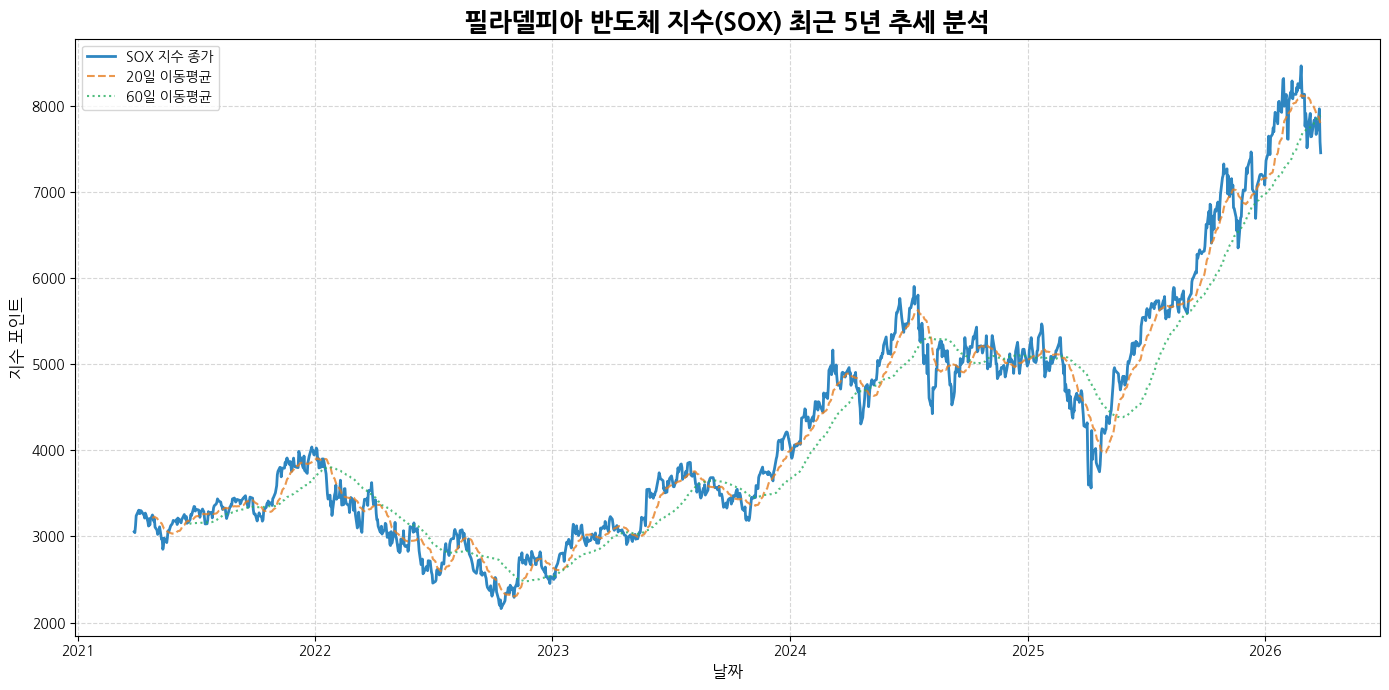

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import koreanize_matplotlib  # <-- 이 줄 하나면 한글 설정 끝!

# 1. SOX 데이터 수집
ticker_symbol = "^SOX" 
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')

print(f"{ticker_symbol} 데이터 수집 중...")
sox_df = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True)

# yfinance 최신 버전의 Multi-index 컬럼 대응
if isinstance(sox_df.columns, pd.MultiIndex):
    sox_df.columns = sox_df.columns.get_level_values(0)

# 2. 데이터 가공 (수익률 및 이동평균)
sox_df['Daily Return'] = sox_df['Close'].pct_change() * 100
sox_df['MA20'] = sox_df['Close'].rolling(window=20).mean()
sox_df['MA60'] = sox_df['Close'].rolling(window=60).mean()

# 3. CSV 파일 저장
sox_df.to_csv("sox_index_5yr_korean.csv")

# 4. 한글이 적용된 시각화
plt.figure(figsize=(14, 7))

# 주가 및 이동평균선
plt.plot(sox_df['Close'], color='#2E86C1', label='SOX 지수 종가', linewidth=2)
plt.plot(sox_df['MA20'], color='#E67E22', label='20일 이동평균', linestyle='--', alpha=0.8)
plt.plot(sox_df['MA60'], color='#27AE60', label='60일 이동평균', linestyle=':', alpha=0.8)

# 그래프 꾸미기
plt.title('필라델피아 반도체 지수(SOX) 최근 5년 추세 분석', fontsize=18, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('지수 포인트', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
